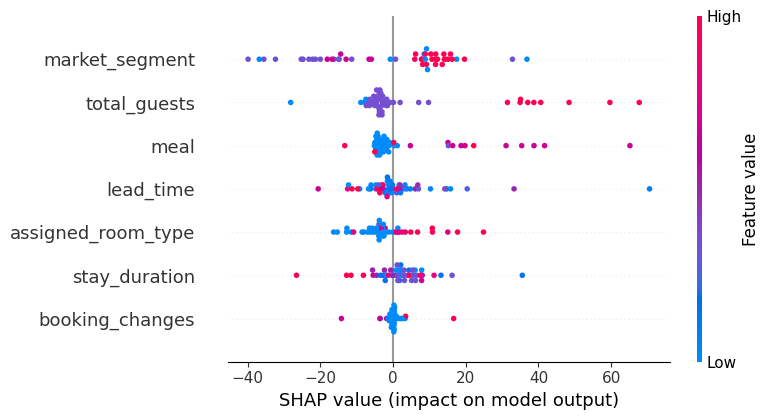

In [2]:
import pandas as pd
import shap
import joblib
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load data and model
df = pd.read_csv('../data/processed/hotel_bookings_processed.csv')
model = joblib.load('../models/hotel_price_model.pkl')

# Select features
features = ['lead_time', 'stay_duration', 'total_guests', 'meal', 'market_segment', 'assigned_room_type', 'booking_changes']
X = df[features]
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# Sample VERY small test set for SHAP (to save memory)
X_test_sample = X_test.sample(50, random_state=42)  # 🚨 only 50 rows!!

# Use TreeExplainer (specific for RandomForest)
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_sample)

# Plot summary (for regression models, shap_values is an array, not list)
shap.summary_plot(shap_values, X_test_sample)
